# Galactic Binaries with LISA: from Source to Parameter Estimation

**Goal.** Follow one galactic binary (GB) from the sky to the posterior:

1. **The source**: what a GB is, why we care, how its parameters map to a signal.
2. **The data**: LISA output = signal + noise.
3. **SNR**: matched filtering across frequency and sky position.
4. **Likelihood and priors**: Bayes' theorem and fitting one GB with the noise known.
5. **Extra**: what happens if we fit the noise as well.

Heavy lifting lives in `GBEx_utils.py`. You only need to read, run, and change a few parameters.
Cells marked **Try it** are for you to modify.

## Setup

Run the install line only on Google Colab.

In [1]:
# Colab only: uncomment, run once, then Runtime -> Restart session
%pip install --upgrade pip && pip cache purge && pip install corner healpy eryn lisaorbits segwo pytdi jaxgb lisaconstants ipywidgets jupyter "numpy==2.3.3" ipywidgets
# Colab: get the utils file next to the notebook (replace with the real URL of your repository)
!wget -q https://raw.githubusercontent.com/coen-rondeel/gb-basics/main/GBEx_utils.py

Files removed: 2 (40 kB)
Directories removed: 6
Note: you may need to restart the kernel to use updated packages.
/bin/bash: wget: command not found


In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)  # GW phases need float64

from GBEx_utils import *   # helpers: sources, GBAnalysis, priors, MCMC, plots

print("JAX devices:", jax.devices())

/opt/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


JAX devices: [CpuDevice(id=0)]


## Choose your source

Everything below re-runs for any source in the table. **Try it:** change `SOURCE_NAME`, then use *Run All*.

In [3]:
print_sources_table()

name         type       f0 [mHz] fdot [1e-17] A [1e-23]  cos(i) dL [kpc]   lam   beta
HM Cnc       AM CVn        6.220       72.500      4.22    0.79     7.50  2.10  -0.08
ZTF J1539    DWD           4.822       27.600      9.23    0.10     2.47  3.58   1.15
SDSS J0651   DWD           2.614        3.350     15.79    0.05     0.96  1.77   0.10
CD-30 11223  sdB           0.473        0.015     39.27    0.12     0.36  3.86  -0.29
ES Cet       sdB           3.225       -1.660      9.26    0.50     1.78  0.43  -0.35
Synthetic 1  Benchmark     3.500        2.000      8.77    1.00     2.10  1.00   1.40
Synthetic 2  Benchmark     3.500        2.000      8.77    0.50     2.10  2.50   0.05


In [4]:
SOURCE_NAME = "HM Cnc"   # try: "ZTF J1539", "SDSS J0651", "ES Cet", "Synthetic 1", ...

# 1. The source: a galactic binary

## What is it, where is it, why do we care?

A galactic binary is a pair of compact stars (mostly white dwarfs, sometimes helium stars) orbiting each other in the Milky Way
with periods of minutes to hours. They emit gravitational waves (GWs) at twice the orbital frequency:

$$f_0 = \frac{2}{P_{\rm orb}} \sim 0.1 - 10\,\mathrm{mHz},$$

right in the LISA band. Why do we care?

* **Millions of them**: LISA will individually resolve on the order of $10^4$ binaries and see the rest as a confusion foreground that must be modeled to find other sources.
* **Verification binaries**: known systems seen in light (e.g. by Gaia, ZTF) that LISA *must* see. They test the instrument and the analysis.
* **Astrophysics**: masses, distances, mass transfer, tides, and the structure of the Galaxy.

## From physical properties to the signal

Over LISA's lifetime a circular binary is almost monochromatic. Eight numbers describe the signal:

| Parameter | Meaning | Physical origin |
|---|---|---|
| $f_0$ | GW frequency | $2/P_{\rm orb}$ |
| $\dot f_0$ | frequency drift | GW radiation reaction ($\mathscr{M}_c$), mass transfer |
| $\mathscr{A}$ | amplitude | $\propto \mathscr{M}_c^{5/3} f_0^{2/3} / d_L$ |
| $\beta, \lambda$ | ecliptic latitude, longitude | sky position |
| $\iota$ | inclination | orientation of the orbit |
| $\psi$ | polarization angle | orientation on the sky |
| $\phi_0$ | initial phase | orbital phase at $t_0$ |

With $\mathscr{M}_c = (m_1 m_2)^{3/5}/(m_1+m_2)^{1/5}$:

$$\mathscr{A} = \frac{2 (G\mathscr{M}_c)^{5/3} (\pi f_0)^{2/3}}{c^4 d_L},\qquad
\dot f_{\rm GW} = \frac{96}{5}\pi^{8/3}\left(\frac{G\mathscr{M}_c}{c^3}\right)^{5/3} f_0^{11/3}.$$ 

If $\dot f_0$ is measured and driven by GWs only, it fixes $\mathscr{M}_c$ and therefore the distance: $d_L = \frac{5c}{48\pi^2}\frac{\dot f_{\rm GW}}{f_0^3\mathscr{A}}$.

In [5]:
physical_summary(SOURCE_NAME)

HM Cnc: m1=0.55 Msun, m2=0.27 Msun, dL=7.5 kpc, f0=6.220 mHz
  chirp mass            : 0.331 Msun
  fdot (GW-driven)      : 7.484e-16 Hz/s   (table: 7.250e-16)
  amplitude from Mc, dL : 4.252e-23      (table: 4.220e-23)
  dL from (fdot, f0, A) : 7.32 kpc        (table: 7.5)


**Question.** Why are some of these sources interesting for LISA? Look at the frequency, the amplitude, and the sign of $\dot f$ in the table.

## The wave itself

In the source frame the two polarizations are (with $\Phi(t)=\phi_0+2\pi(f_0 t+\tfrac12\dot f_0 t^2)$)

$$h_+ = \mathscr{A}(1+\cos^2\iota)\cos\Phi(t),\qquad h_\times = 2\mathscr{A}\cos\iota\,\sin\Phi(t).$$

Face-on ($\iota=0$) gives circular polarization; edge-on ($\iota=\pi/2$) gives purely linear polarization.

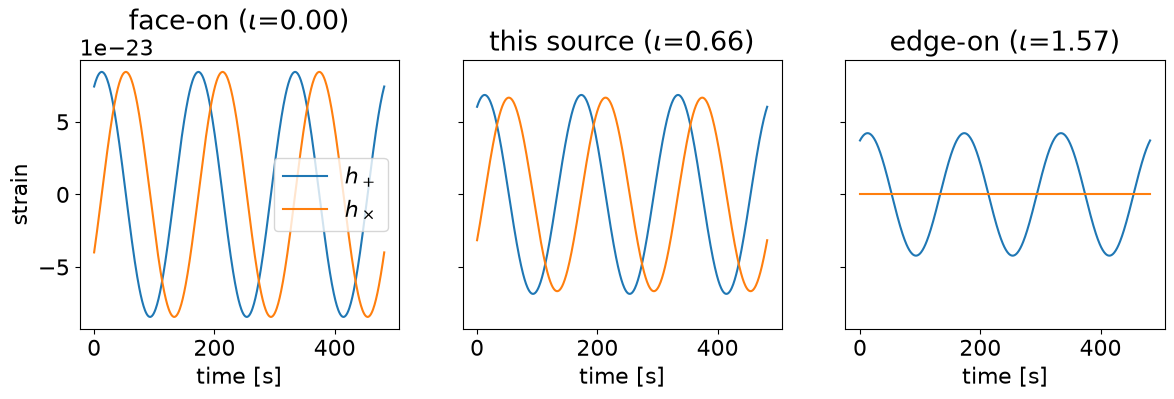

In [6]:
src = get_source(SOURCE_NAME)
t = np.linspace(0, 3 / src[0], 600)   # 3 GW cycles
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, iota, lab in zip(axes, [0.0, src[6], np.pi / 2], ["face-on", "this source", "edge-on"]):
    hp_, hx_ = strain_polarizations(t, src[0], src[1], src[2], iota, src[7])
    ax.plot(t, hp_, label=r"$h_+$"); ax.plot(t, hx_, label=r"$h_\times$")
    ax.set_title(f"{lab} ($\\iota$={iota:.2f})"); ax.set_xlabel("time [s]")
axes[0].set_ylabel("strain"); axes[0].legend()
plt.show()

## Orientation and the two polarizations

A gravitational wave stretches space transversely to its direction of travel. For a ring of free masses facing the source:

* $h_+$ stretches along one axis while squeezing along the perpendicular one (the "+" pattern);
* $h_\times$ does the same along axes rotated by $45^\circ$.

The inclination $\iota$ is the angle between the orbital axis and the line of sight to LISA. It sets the mix of the two polarizations:

* **Face-on** ($\cos\iota=\pm1$): $h_+$ and $h_\times$ have equal amplitude and are $90^\circ$ out of phase. The stretching axis rotates with the orbit, once per orbit. We see a circular wave.
* **Edge-on** ($\cos\iota=0$): only $h_+$ survives, the axis stays fixed and the wave is linear, with half the amplitude of the face-on case.

A single LISA arm only feels the component of the stretching along its own direction, $\Delta L/L=\tfrac12\,[h_+\cos2\alpha+h_\times\sin2\alpha]$, where $\alpha$ is the angle between the arm and the $+$ axis. The red arm below does this: it oscillates at **twice the orbital frequency** because the stretching pattern repeats after half an orbit.

The animation shows the binary in 3D, the same orbit as seen from LISA, the ring and arm (strain strongly exaggerated), and the resulting strains over one orbit.

In [7]:
from IPython.display import display

# Use the play controls under the figure; psi rotates the polarization axes, arm_angle sets the arm direction
display(animate_binary_gw(cos_iota=np.cos(src[6]), psi=src[5], arm_angle=0.0))

**Try it:** change the inclination, polarization angle and arm direction, then press *Run Interact* to render a new animation.

* Set $\cos\iota=\pm1$: does the red arm still oscillate? Does its amplitude depend on the arm direction?
* Set $\cos\iota=0$: which arm directions see the largest and the smallest signal? What happens at $\alpha-\psi=\pm45^\circ$?
* Flip the sign of $\cos\iota$: what changes in the orbit seen from LISA, and what changes in the ring?

In [8]:
interactive_binary_animation()

interactive(children=(FloatSlider(value=0.79, description='cos(iota)', max=1.0, min=-1.0, step=0.05), FloatSli…

## From $h_+$ and $h_\times$ to TDI data

A binary emits two transverse polarizations. For the circular-binary convention used in this tutorial,

$$h_+(t)=\mathscr{A}(1+\cos^2\iota)\cos\Phi(t),\qquad
h_\times(t)=2\mathscr{A}\cos\iota\sin\Phi(t).$$

These are not yet the data measured by LISA. Each directed laser link measures a fractional-frequency shift. The passing wave changes the light travel time, and therefore the received laser frequency. The response depends on link direction, sky position, spacecraft motion and light travel time. In the frequency domain we can summarize one link's response as

$$\tilde y_\ell(f)=R_{\ell+}(f)\tilde h_+(f)+R_{\ell\times}(f)\tilde h_\times(f),$$

where $\ell$ labels one of the six directed links. The response factors include propagation delays and the finite-arm response; they are not just a constant projection of $h_+$ or $h_\times$.

### TDI combinations

The six links contain enormous laser-frequency noise. Time-Delay Interferometry (TDI) combines delayed copies of the link measurements so that the laser noise cancels (to the accuracy of the chosen TDI generation). A simplified map of the signal path is

$$ (h_+,h_\times)\;\xrightarrow{\,\text{LISA link response}\,}\;(y_1,\ldots,y_6)\;\xrightarrow{\,\text{delayed TDI combinations}\,}\;(X,Y,Z)\;\xrightarrow{\,\text{orthogonal channel rotation}\,}\;(A,E,T). $$

For this tutorial's normalization, the final rotation is

$$A=\frac{Z-X}{\sqrt2},\qquad E=\frac{X-2Y+Z}{\sqrt6},\qquad T=\frac{X+Y+Z}{\sqrt3}.$$

`compute_strain2x` is a utility helper that composes `segwo`'s strain-to-link response with `pytdi`'s link-to-TDI mixing. It is **not** called by the notebook's `GBAnalysis` injection. The notebook instead uses `MyJaxGB`, which calls `jaxgb.get_tdi` configured for second-generation TDI and the AET combination. These are distinct implementations of the response. In either route, the template returned to the notebook is already frequency-domain A, E and T data, not $h_+$ and $h_\times$ and not raw link measurements.

### Instrument noise and the simulated data

The noise model starts with optical-metrology (OMS) displacement noise and test-mass (TM) acceleration noise, modeled as independent sources on the links. `compute_covariance` converts their reference spectra to fractional-frequency units, builds the link-noise covariance, and projects it through the delayed TDI mixing into the A/E/T basis. The covariance is averaged over ten orbit-time samples to obtain an approximately stationary frequency-dependent matrix $\mathbf C_{AET}(f)$.

For each frequency bin, the code draws a complex Gaussian channel vector:

$$\mathbf n_k=\mathbf L_k\mathbf z_k,\qquad
\mathbf L_k\mathbf L_k^\dagger=\frac{\mathbf C_{AET}(f_k)}{2\Delta f},\qquad
\mathbf z_k\sim{N}(\mathbf 0,\mathbf I).$$

Thus $\mathbb{E}[\mathbf n_k\mathbf n_k^\dagger]=\mathbf C_{AET}(f_k)/(2\Delta f)$. The Cholesky factor preserves any A/E/T correlations in a bin; independent draws are made for different frequency bins. The simulated observation is

$$\mathbf d_k=\mathbf s_{AET,k}+\mathbf n_k.$$

This is a **frequency-domain toy observation**, not a time series that is Fourier transformed. The tutorial assumes equal-arm second-generation TDI, averages the changing noise covariance over time, neglects correlations between frequency bins, and uses the diagonal PSD in the main likelihood. The generated noise can retain small cross-channel correlations even though the likelihood ignores them. Realistic unequal, flexing arms and the unresolved-binary foreground require a more complete model.

`GBAnalysis` performs this setup for a one-year observation. The cell below constructs the data, and the following plot compares its signal and noise power.

In [9]:
analysis = GBAnalysis(get_source(SOURCE_NAME))
print(f"T_obs = {analysis.tobs/86400:.1f} days, df = {analysis.df:.2e} Hz, {analysis.n_bins} frequency bins around f0")
print("Optimal SNR of the injection:", round(analysis.optimal_snr(analysis.signal), 1))

T_obs = 365.3 days, df = 3.17e-08 Hz, 128 frequency bins around f0
Optimal SNR of the injection: 45.0


**Try it:** move the sliders. Which parameters change the *overall power* in A, E, T, and which change how it is *shared* between channels or *shaped* in frequency?

In [ ]:
interactive_waveform_explorer(analysis)

interactive(children=(FloatSlider(value=0.79, description='cos(iota)', max=1.0, min=-1.0, step=0.05), FloatSli…

# 2. The data: signal + noise

$$d(t) = h(t;\boldsymbol\theta) + n(t).$$

We work in the frequency domain. The noise is Gaussian and described by its one-sided power spectral density $S_n(f)$:
in each frequency bin of width $\Delta f = 1/T_{\rm obs}$ the complex noise has variance $S_n(f)/(2\Delta f)$.
(The instrument noise itself is covered in the previous tutorial.)

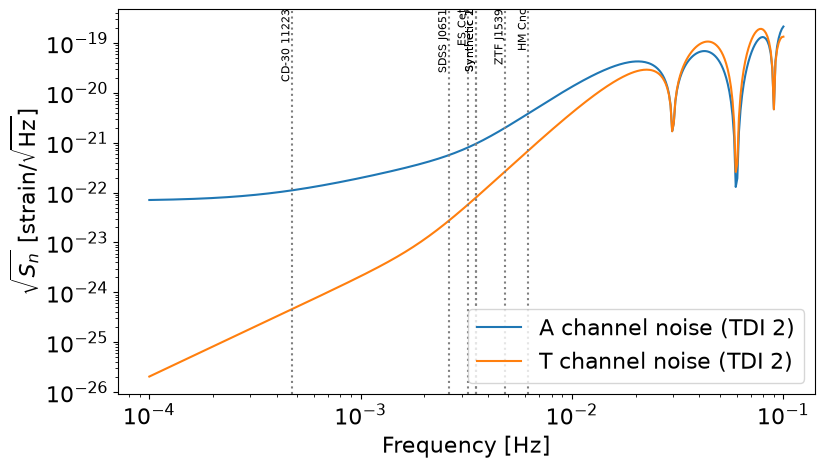

In [11]:
plot_noise_curve(analysis, source_names=list(SOURCES))

Each source sits at its own frequency, where the noise level is different. Zooming in on the injected source:

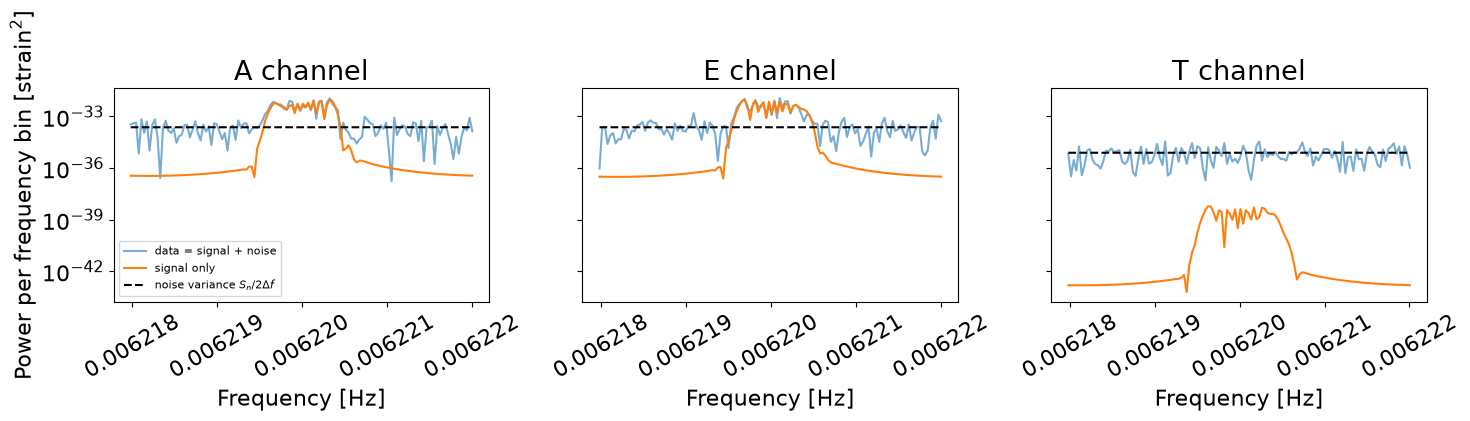

In [12]:
analysis.plot_data()

Different sources have visibly different shapes: the amplitude modulation from LISA's motion is stronger for higher $f_0$ and for sources near the ecliptic plane.

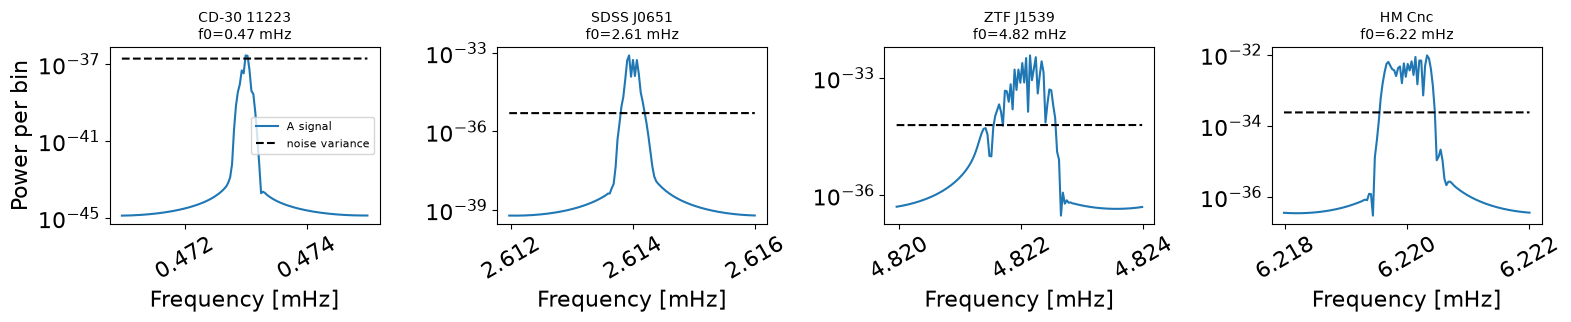

In [13]:
plot_reference_sources(["CD-30 11223", "SDSS J0651", "ZTF J1539", "HM Cnc"])

**Optional: noise structure.** In the AET basis the cross-spectral matrix (CSD) is almost diagonal, so we can treat A, E, T independently.

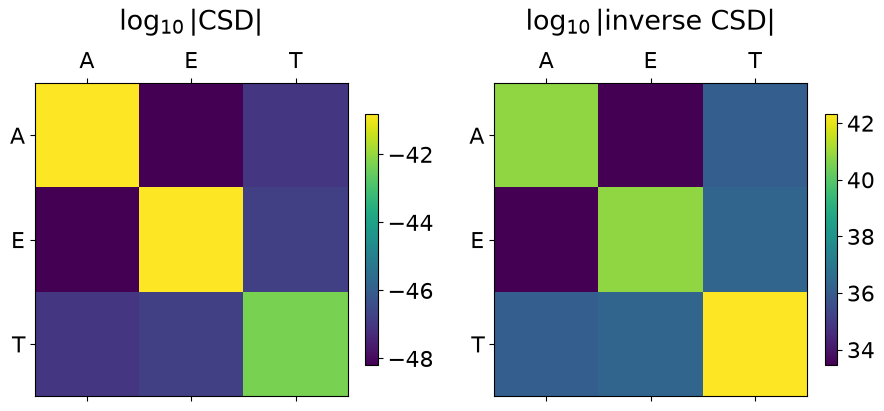

In [14]:
analysis.plot_covariance_structure()

# 3. Signal-to-noise ratio and matched filtering

For a template $h$, the noise-weighted inner product is

$$\langle a | b\rangle = 4\Delta f\ \mathrm{Re}\sum_{X\in\{A,E,T\}}\sum_k \frac{\tilde a_X^*(f_k)\,\tilde b_X(f_k)}{S_{n,X}(f_k)}.$$

* **Intrinsic (optimal) SNR**: $\rho_{\rm opt}=\sqrt{\langle h|h\rangle}$. How loud the source is in this noise.
* **Matched-filter SNR** on data $d$: $\rho_{\rm MF}=\langle d|h\rangle/\sqrt{\langle h|h\rangle}$. On signal + noise it is a Gaussian with mean $\rho_{\rm opt}$ and unit variance.

optimal SNR           : 44.97
matched-filter SNR    : 45.23   (this noise realization)


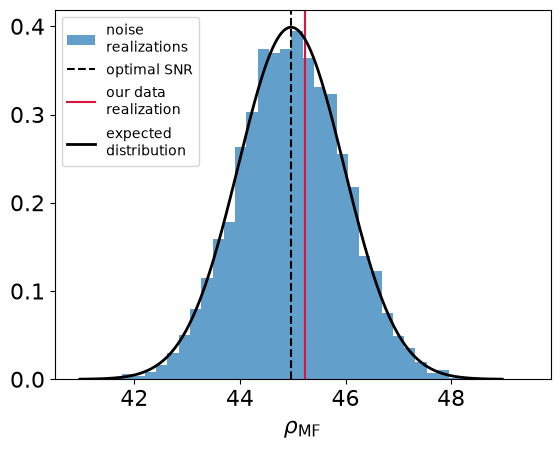

mean = 44.98, std = 1.00  (expected: 44.97, 1.00)


In [15]:
rho_opt = analysis.optimal_snr(analysis.signal)
rho_mf = float(analysis.matched_filter_snr(analysis.data, analysis.signal))
print(f"optimal SNR           : {rho_opt:.2f}")
print(f"matched-filter SNR    : {rho_mf:.2f}   (this noise realization)")

rho_many = analysis.snr_realizations(n_real=10000)
plt.hist(rho_many, bins=40, density=True, alpha=0.7, label="noise \nrealizations")
# gaussian with mean=optimal SNR, std=1.0
x = np.linspace(rho_opt - 4, rho_opt + 4, 200)
plt.axvline(rho_opt, color="k", ls="--", label="optimal SNR")
plt.axvline(rho_mf, color="crimson", label="our data \nrealization")
plt.plot(x, 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * (x - rho_opt) ** 2), color="k", lw=2, label="expected \ndistribution")
plt.xlabel(r"$\rho_{\rm MF}$"); 
plt.legend(loc="upper left", fontsize=10); 
plt.show()
print(f"mean = {rho_many.mean():.2f}, std = {rho_many.std():.2f}  (expected: {rho_opt:.2f}, 1.00)")

## SNR across frequency

We shift the template frequency by a few bins and recompute the SNRs. The matched-filter SNR peaks at the true frequency, and its width tells us how precisely $f_0$ can be measured, of order a few $\Delta f$.

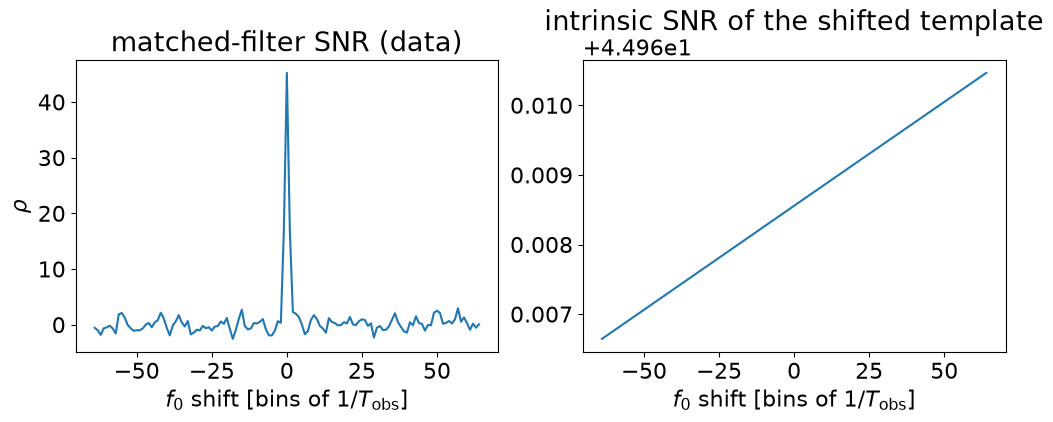

In [16]:
offsets = np.arange(-analysis.pad, analysis.pad + 1)
mf_f, opt_f = analysis.snr_vs_frequency(offsets)
f_scan = analysis.source_params[0] + offsets * analysis.df

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(offsets, mf_f); ax[0].set_title("matched-filter SNR (data)")
ax[1].plot(offsets, opt_f); ax[1].set_title("intrinsic SNR of the shifted template")
for a in ax: a.set_xlabel(r"$f_0$ shift [bins of $1/T_{\rm obs}$]")
ax[0].set_ylabel(r"$\rho$"); plt.show()

## SNR across the sky

We keep every parameter but $(\beta,\lambda)$ fixed and scan the sky with a HEALPix grid (low resolution for speed).

* The **intrinsic SNR** map says where on the sky the same source would be louder or quieter, which is the antenna pattern and the orbital modulation.
* The **matched-filter SNR** map on our data shows where the injected source is located.

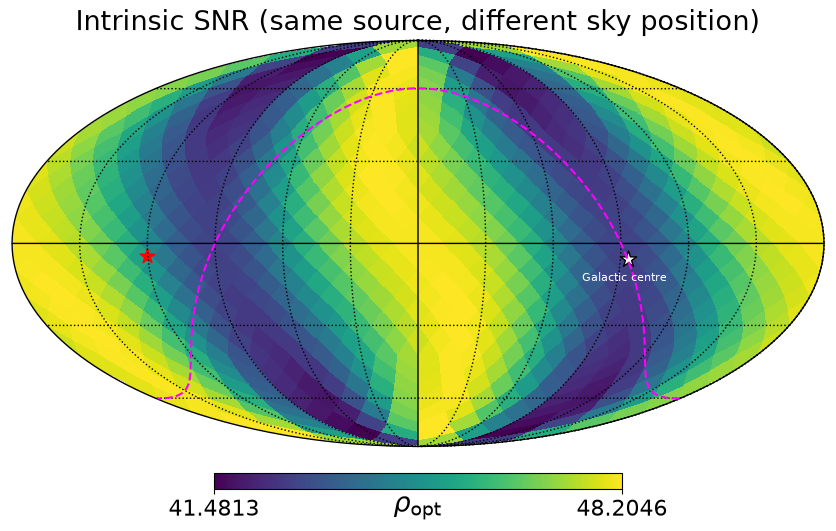

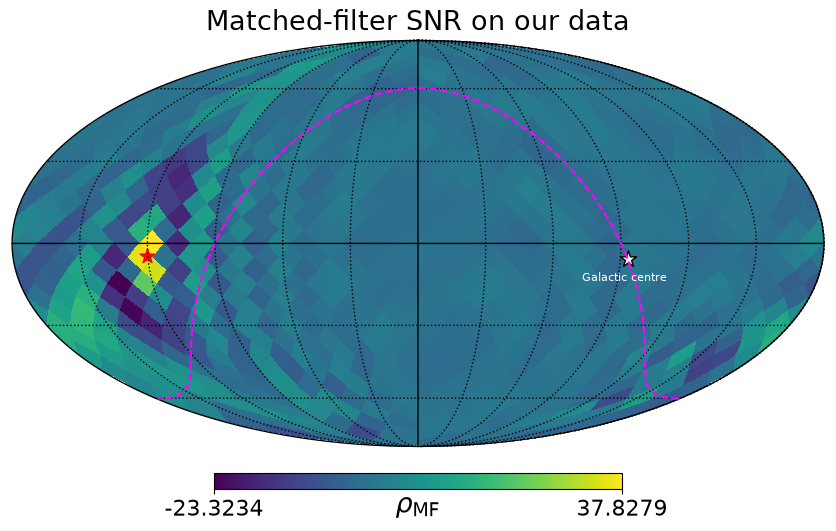

In [17]:
NSIDE_SCAN = 8   # 768 pixels; increase for sharper maps (slower)
mf_sky, opt_sky = analysis.snr_vs_sky(nside=NSIDE_SCAN)
truth_sky = (analysis.source_params[3], analysis.source_params[4])
plot_sky_map(opt_sky, "Intrinsic SNR (same source, different sky position)", r"$\rho_{\rm opt}$", truth=truth_sky)
plot_sky_map(mf_sky, "Matched-filter SNR on our data", r"$\rho_{\rm MF}$", truth=truth_sky)

**Questions.** Is the best-matching pixel the true one? Why is the matched-filter map broad when the SNR is low? What changes for a source at high ecliptic latitude (try `"Synthetic 1"`)?

In [ ]:
interactive_sky_snr(analysis, nside=NSIDE_SCAN)

Sliders mode. For click-to-select run `%matplotlib widget` first (needs ipympl).


interactive(children=(FloatSlider(value=-0.08, description='beta', max=1.5707963267948966, min=-1.570796326794…

# 4. Likelihood, priors and fitting one GB (known noise)

Bayes' theorem:

$$p(\boldsymbol\theta|d) = \frac{p(d|\boldsymbol\theta)\,\pi(\boldsymbol\theta)}{p(d)}.$$

For Gaussian noise the log-likelihood is

$$\ln p(d|\boldsymbol\theta) = -\tfrac12\langle d-h(\boldsymbol\theta)\,|\,d-h(\boldsymbol\theta)\rangle + {\rm const.}$$

The constant (the noise determinant) is dropped because the noise is known and fixed.

Before sampling, two sanity checks: the template at the true parameters must match the injection (mismatch $\approx 0$), and moving $f_0$ away must lower $\ln p(d|\boldsymbol\theta)$.

In [19]:
loglike = analysis.make_log_likelihood(fit_noise=False)
truth = analysis.source_params.copy()

h_true = analysis.template(analysis.source_params)
print("mismatch(template, injection):", mismatch(h_true, analysis.signal, analysis.inv_psd, analysis.df))
print("ln L at truth:", loglike(truth)[0])

shifted = truth.copy(); shifted[0] += 20 * analysis.df
print("ln L, f0 off by 20 bins:", loglike(shifted)[0])

mismatch(template, injection): 0.0
ln L at truth: -390.4843874034927
ln L, f0 off by 20 bins: -2414.49215260213


## Priors

All priors are specified directly in the physical parameters used by the waveform:

* $f_0$: uniform in a $\pm1\,\mu$Hz window (a search pipeline has already localized the source; a blind run over the full band is impractical).
* $\dot f_0 \in [-10^{-15}, 3\times10^{-15}]$ Hz/s, allowing GW-driven chirps and mass-transferring (negative) systems. The window must be wide compared with the posterior (a few $10^{-16}$ Hz/s for a one-year observation), otherwise it truncates the posterior.
* $\mathscr{A}\in[\mathscr{A}_0/4,\,4\mathscr{A}_0]$.
* Sky latitude $\beta$ and inclination $\iota$ are uniform over their physical ranges, not isotropic. Periodic angles are $\lambda,\phi_0\in[0,2\pi)$ and $\psi\in[0,\pi)$ (rotating the polarization basis by $\pi$ leaves the signal unchanged).
* Posteriors near a boundary can be physical: $\iota\to0$ is face-on, where $\psi$ and $\phi_0$ become degenerate. Periodic angles also wrap around their endpoints.

In [20]:
priors, periodic, ndims, bounds = make_priors(
    analysis.source_params[0], 1e-6, A_center=analysis.source_params[2])
for lbl, (lo, hi) in zip(get_parameter_labels(), bounds):
    print(f"{lbl:<16} [{lo:.3e}, {hi:.3e}]")

$f_0$ [Hz]       [6.219e-03, 6.221e-03]
$\dot f_0$ [Hz/s] [-1.000e-15, 3.000e-15]
$A$              [1.055e-23, 1.688e-22]
$\beta$          [-1.571e+00, 1.571e+00]
$\lambda$        [0.000e+00, 6.283e+00]
$\psi$           [0.000e+00, 3.142e+00]
$\iota$          [0.000e+00, 3.142e+00]
$\phi_0$         [0.000e+00, 6.283e+00]


## Sampling the posterior

We use `eryn` (ensemble sampler with parallel tempering). Walkers start in a small ball around the injected values, as after a detection pipeline.
Only the coldest chain ($T=1$) is the posterior.

The first call compiles the likelihood with JAX. Reduce `N_ITER` for a quick look, increase it for smoother posteriors.

In [21]:
import time
NWALKERS, NTEMPS = 22, 2
N_ITER, N_BURN = 2000, 1000

tic = time.time()
sampler = run_gb_mcmc(loglike, priors, periodic, ndims, bounds, truth,
                      nwalkers=NWALKERS, ntemps=NTEMPS, n_iterations=N_ITER, burn=N_BURN)
print(f"MCMC finished in {time.time() - tic:.0f} s")

100%|██████████| 2000/2000 [00:16<00:00, 121.70it/s]

MCMC finished in 25 s


In [22]:
samples, logl = get_cold_samples(sampler)
labels = get_parameter_labels()
summarize_posterior(samples, truth, labels)

Parameter          | Median             | Std          | Precision  | Bias         | Bias (sigma)
----------------------------------------------------------------------------------------------------
$f_0$ [Hz]         | 6.2199918809e-03   | 5.2371e-09   | 8.42e-07   | -8.1191e-09  | -1.55
$\dot f_0$ [Hz/s]  | 1.1764810537e-15   | 3.2986e-16   | 4.55e-01   | 4.5148e-16   | +1.37
$A$                | 3.8591572845e-23   | 4.9384e-24   | 1.17e-01   | -3.6084e-24  | -0.73
$\beta$            | -7.1349448566e-02  | 6.1281e-03   | 7.66e-02   | 8.6506e-03   | +1.41
$\lambda$          | 2.1104164511e+00   | 7.1953e-03   | 3.43e-03   | 1.0416e-02   | +1.45
$\psi$             | 1.5849926989e+00   | 7.9864e-01   | 3.40e-01   | -7.6501e-01  | -0.96
$\iota$            | 4.9672033004e-01   | 2.4292e-01   | 3.68e-01   | -1.6327e-01  | -0.67
$\phi_0$           | 3.9285611247e+00   | 1.6008e+00   | 2.76e-01   | -1.8614e+00  | -1.16


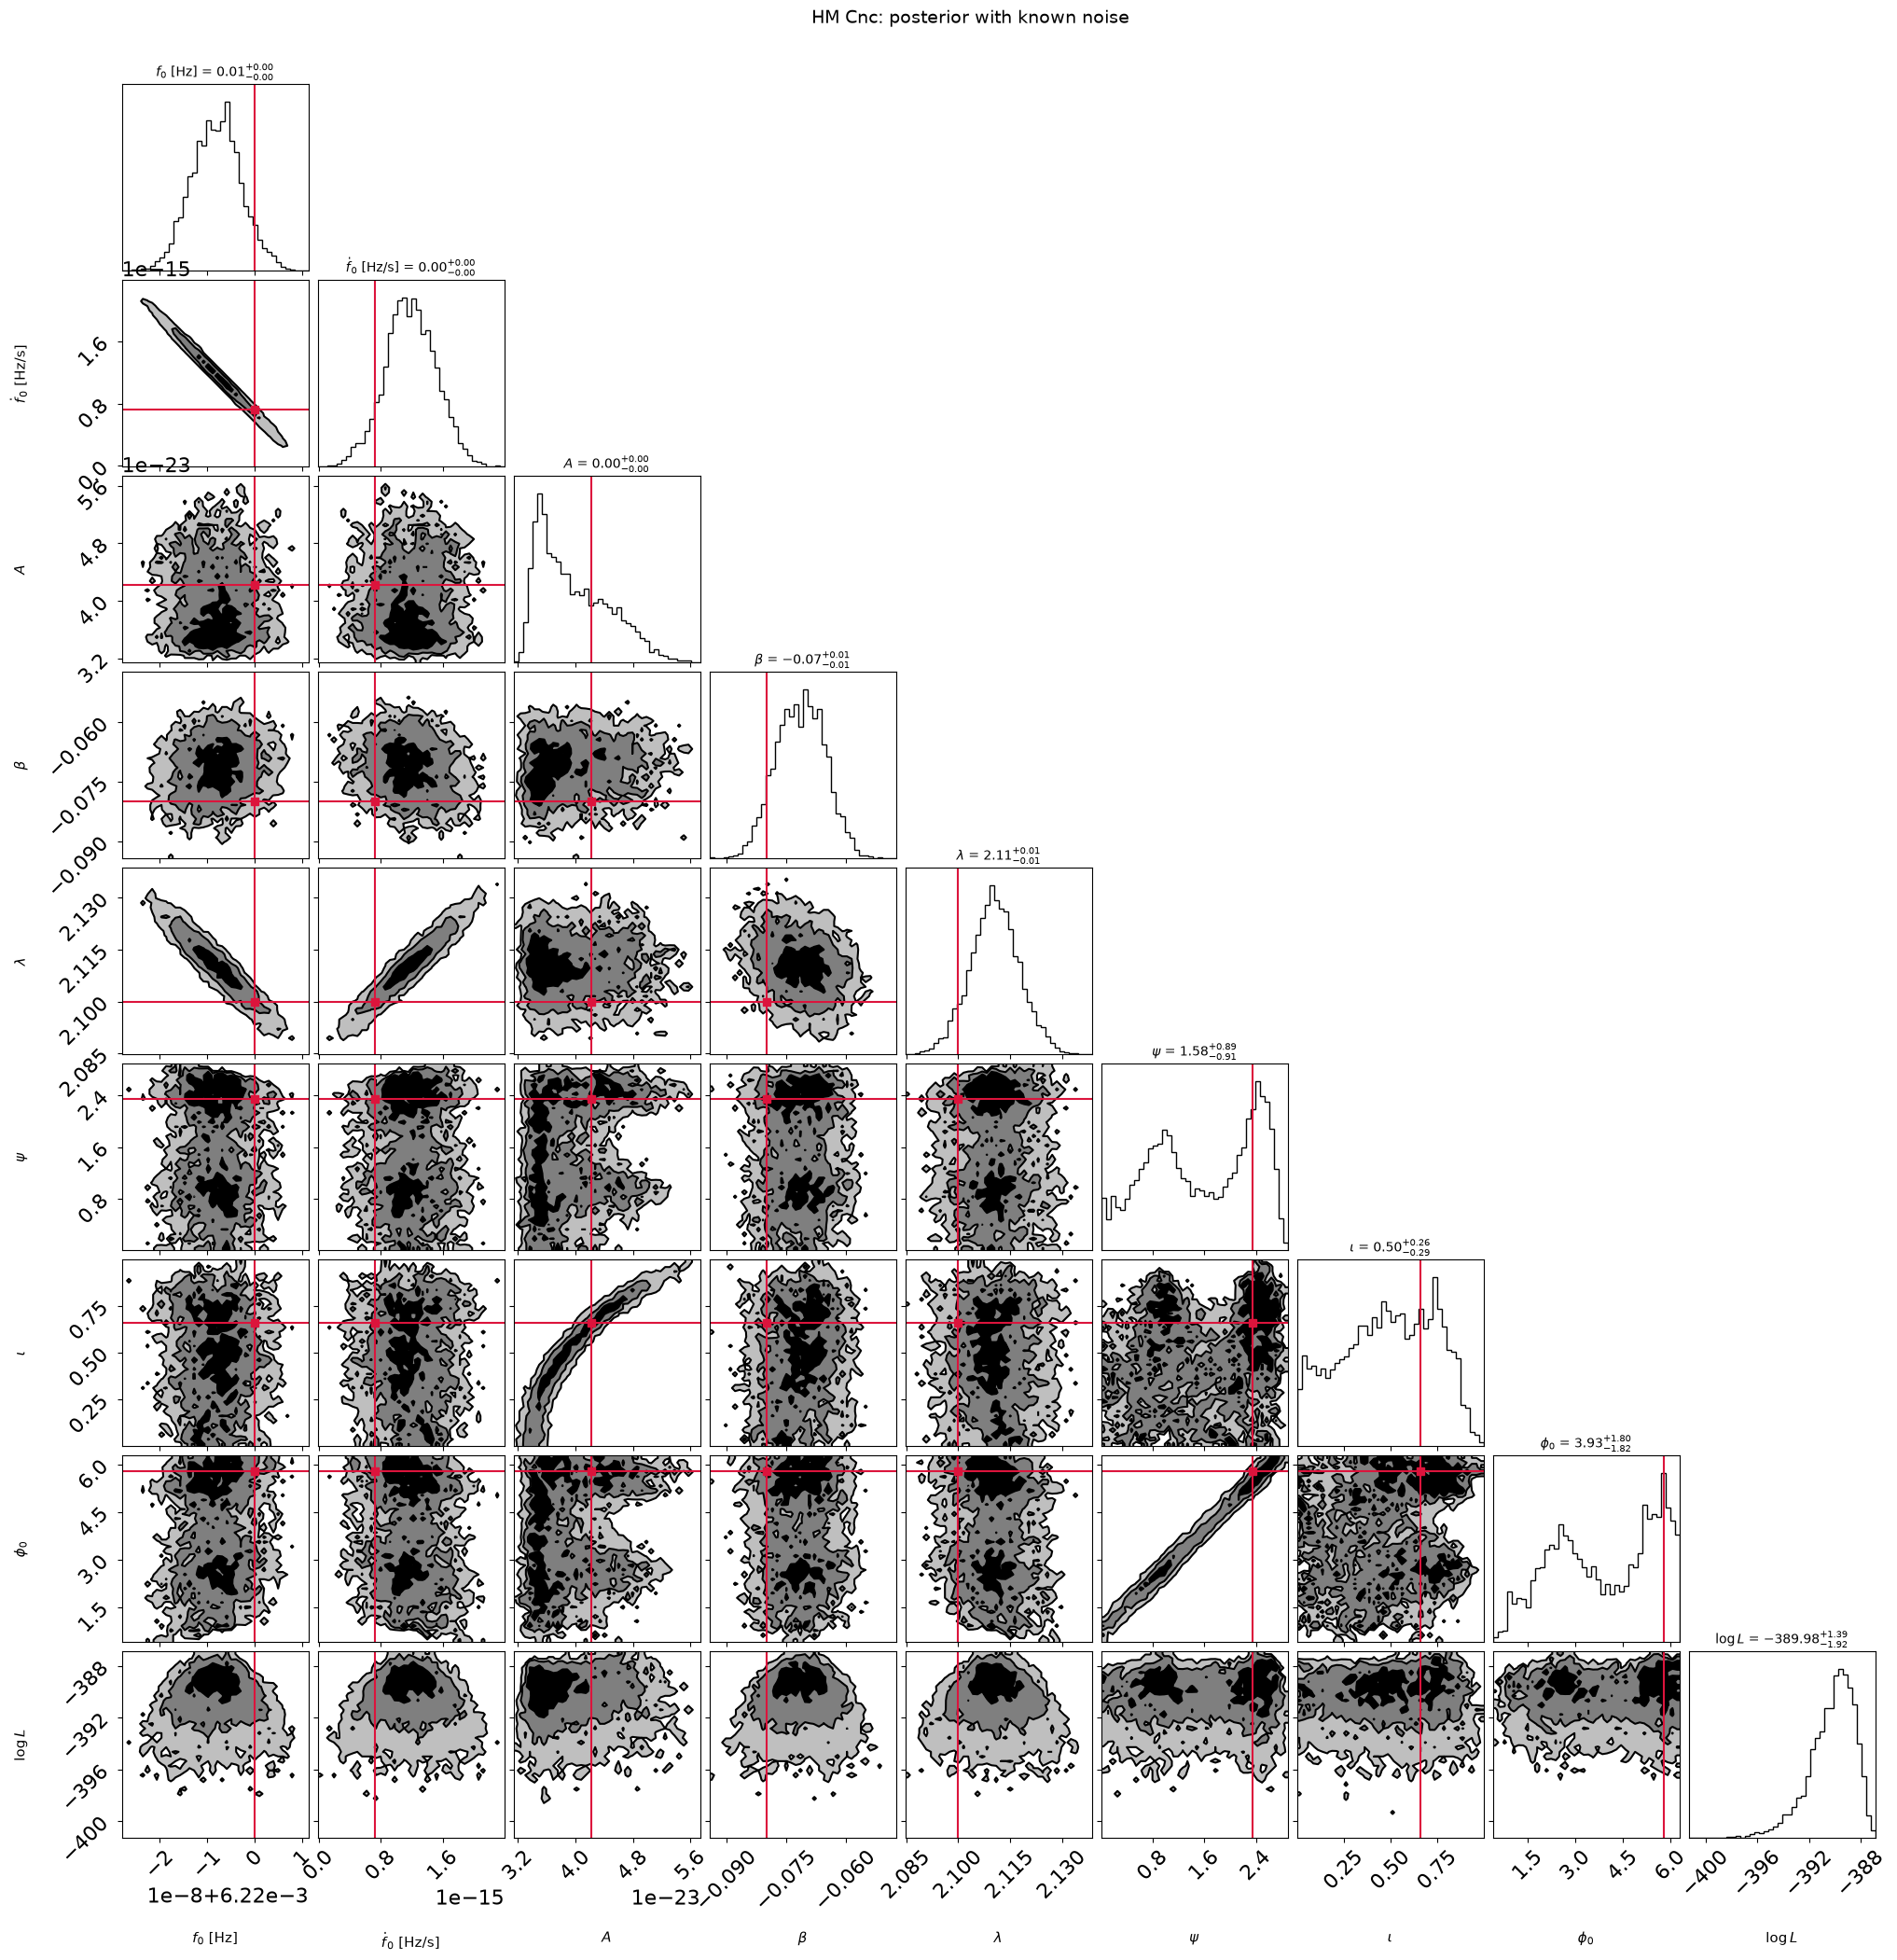

In [23]:
plot_posterior(samples, logl, truth, labels, f"{SOURCE_NAME}: posterior with known noise")

**Questions.**

* Which parameters are measured best? Compare $f_0$ (relative precision $\sim10^{-8}$) with the angles.
* Do you see correlations? Which ones are degeneracies of the signal (e.g. $\mathscr{A}$ vs $\cos\iota$; $\phi_0\to\phi_0+\pi$ with $\psi\to\psi+\pi/2$)?
* Is $\dot f_0$ measured? What would that give us astrophysically?
* Compare the posterior to the SNR maps of Part 3.

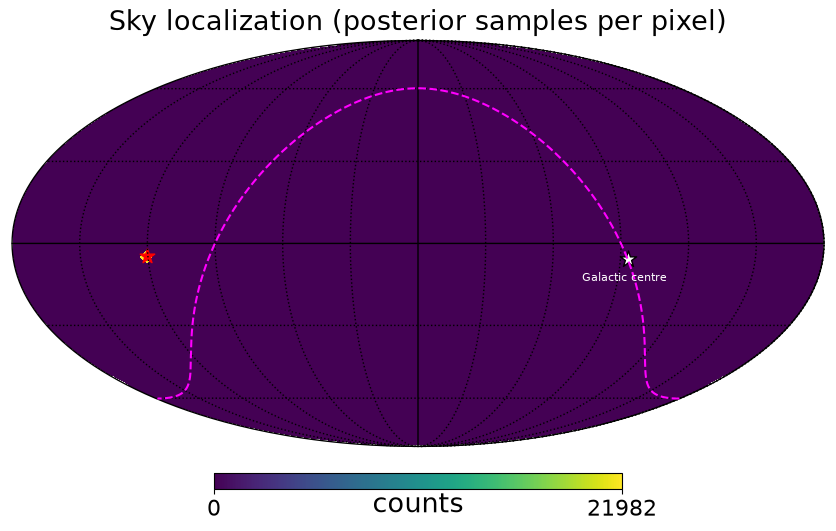

In [24]:
counts = samples_to_sky_counts(samples, nside=16)
plot_sky_map(counts, "Sky localization (posterior samples per pixel)", "counts", truth=truth_sky)

**Questions.** Are the $\sigma$ posteriors centred on the truth? Which GB parameter is most affected by the wrong noise model, and why? When would fitting the noise matter more?

# Exercise

1. Set `SOURCE_NAME` to another verification binary (e.g. `"ZTF J1539"` or `"ES Cet"`) and re-run everything.
2. Compare: SNR, sky localization, precision on $f_0$ and $\dot f_0$.
3. For which sources is $\dot f_0$ measurable? For which is the sky position poorly constrained?

# Extra: fitting the noise as well

Now the noise variance is unknown, so we infer it alongside the source parameters. We use a deliberately **simplified** model: each channel has a frequency-independent complex variance,

$$\mathbb{E}[|n_{X,k}|^2]=\sigma_X^2,\qquad \mathbf{Cov}_{\rm model}=\mathrm{diag}(\sigma_A^2,\sigma_E^2,\sigma_T^2).$$

For one circular complex Gaussian sample, $p(r|\sigma_X^2)=(\pi\sigma_X^2)^{-1}\exp(-|r|^2/\sigma_X^2)$. Multiplying the independent-bin densities across $N_{\rm freq}$ bins and taking the log gives

$$\ln p(d|\boldsymbol\theta,\boldsymbol\sigma)=-\sum_{X\in\{A,E,T\}}\left[N_{\rm freq}\ln(\pi\sigma_X^2)+\frac{\sum_k|r_{X,k}|^2}{\sigma_X^2}\right].$$

There is **no explicit $1/2$** in this expression because it is written for complex samples, whose density has exponent $-|r|^2/\sigma^2$. This is consistent with Part 4: setting $\sigma_X^2=S_{n,X}/(2\Delta f)$ makes the quadratic term exactly $-\tfrac12\langle r|r\rangle$. Equivalently, the usual $1/2$ appears if the likelihood is written for independent real quadratures instead. The normalization $-N_{\rm freq}\ln(\pi\sigma_X^2)$ must remain when fitting $\sigma_X$; without it the likelihood would favor arbitrarily large noise variance.

The injected noise is coloured and can have small cross-channel correlations; this frequency-flat, diagonal model is intentionally approximate. We use it to see how fitting an imperfect noise model can affect the source posterior.

ln L at [truth, sigma0]       : 29339.24505334312
analytic expectation (approx) : 29345.752530663747
ln L, f0 off by 20 bins       : 27314.68227093316


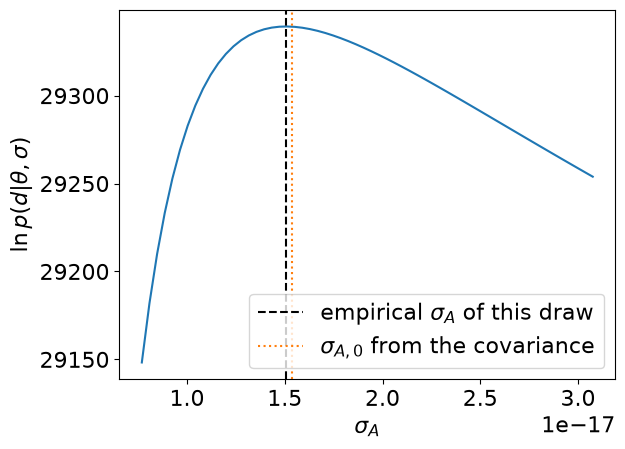

In [25]:
loglike_n = analysis.make_log_likelihood(fit_noise=True)
truth_n = np.concatenate([analysis.source_params, analysis.sigma0])

print("ln L at [truth, sigma0]       :", loglike_n(truth_n)[0])
print("analytic expectation (approx) :", -np.sum(analysis.n_bins * (np.log(np.pi * analysis.sigma0**2) + 1)))
shifted_n = truth_n.copy(); shifted_n[0] += 20 * analysis.df
print("ln L, f0 off by 20 bins       :", loglike_n(shifted_n)[0])

grid = np.linspace(0.5, 2, 60) * analysis.sigma0[0]
pts = np.repeat(truth_n[None], len(grid), axis=0); pts[:, 8] = grid
plt.plot(grid, loglike_n(pts))
plt.axvline(analysis.sigma_empirical[0], color="k", ls="--", label=r"empirical $\sigma_A$ of this draw")
plt.axvline(analysis.sigma0[0], color="C1", ls=":", label=r"$\sigma_{A,0}$ from the covariance")
plt.xlabel(r"$\sigma_A$"); plt.ylabel(r"$\ln p(d|\theta,\sigma)$"); plt.legend(); plt.show()

In [26]:
priors_n, periodic_n, ndims_n, bounds_n = make_priors(
    analysis.source_params[0], 1e-6, A_center=analysis.source_params[2], sigma0=analysis.sigma0)

tic = time.time()
sampler_n = run_gb_mcmc(loglike_n, priors_n, periodic_n, ndims_n, bounds_n, truth_n,
                        nwalkers=NWALKERS, ntemps=NTEMPS, n_iterations=N_ITER, burn=N_BURN)
print(f"MCMC finished in {time.time() - tic:.0f} s")

samples_n, logl_n = get_cold_samples(sampler_n)
labels_n = get_parameter_labels(include_noise=True)
summarize_posterior(samples_n, truth_n, labels_n)

100%|██████████| 2000/2000 [00:16<00:00, 119.90it/s]

MCMC finished in 25 s
Parameter          | Median             | Std          | Precision  | Bias         | Bias (sigma)
----------------------------------------------------------------------------------------------------
$f_0$ [Hz]         | 6.2199922646e-03   | 5.1590e-09   | 8.29e-07   | -7.7354e-09  | -1.50
$\dot f_0$ [Hz/s]  | 1.1469010518e-15   | 3.2498e-16   | 4.48e-01   | 4.2190e-16   | +1.30
$A$                | 3.7766030573e-23   | 5.6338e-24   | 1.34e-01   | -4.4340e-24  | -0.79
$\beta$            | -7.1906270896e-02  | 6.2248e-03   | 7.78e-02   | 8.0937e-03   | +1.30
$\lambda$          | 2.1091551673e+00   | 6.9833e-03   | 3.33e-03   | 9.1552e-03   | +1.31
$\psi$             | 1.4094939123e+00   | 7.8752e-01   | 3.35e-01   | -9.4051e-01  | -1.19
$\iota$            | 4.5311311441e-01   | 2.7689e-01   | 4.20e-01   | -2.0687e-01  | -0.75
$\phi_0$           | 3.5804527445e+00   | 1.5825e+00   | 2.73e-01   | -2.2095e+00  | -1.40
$\sigma_A$         | 1.5270545555e-17   | 6.6108e-1

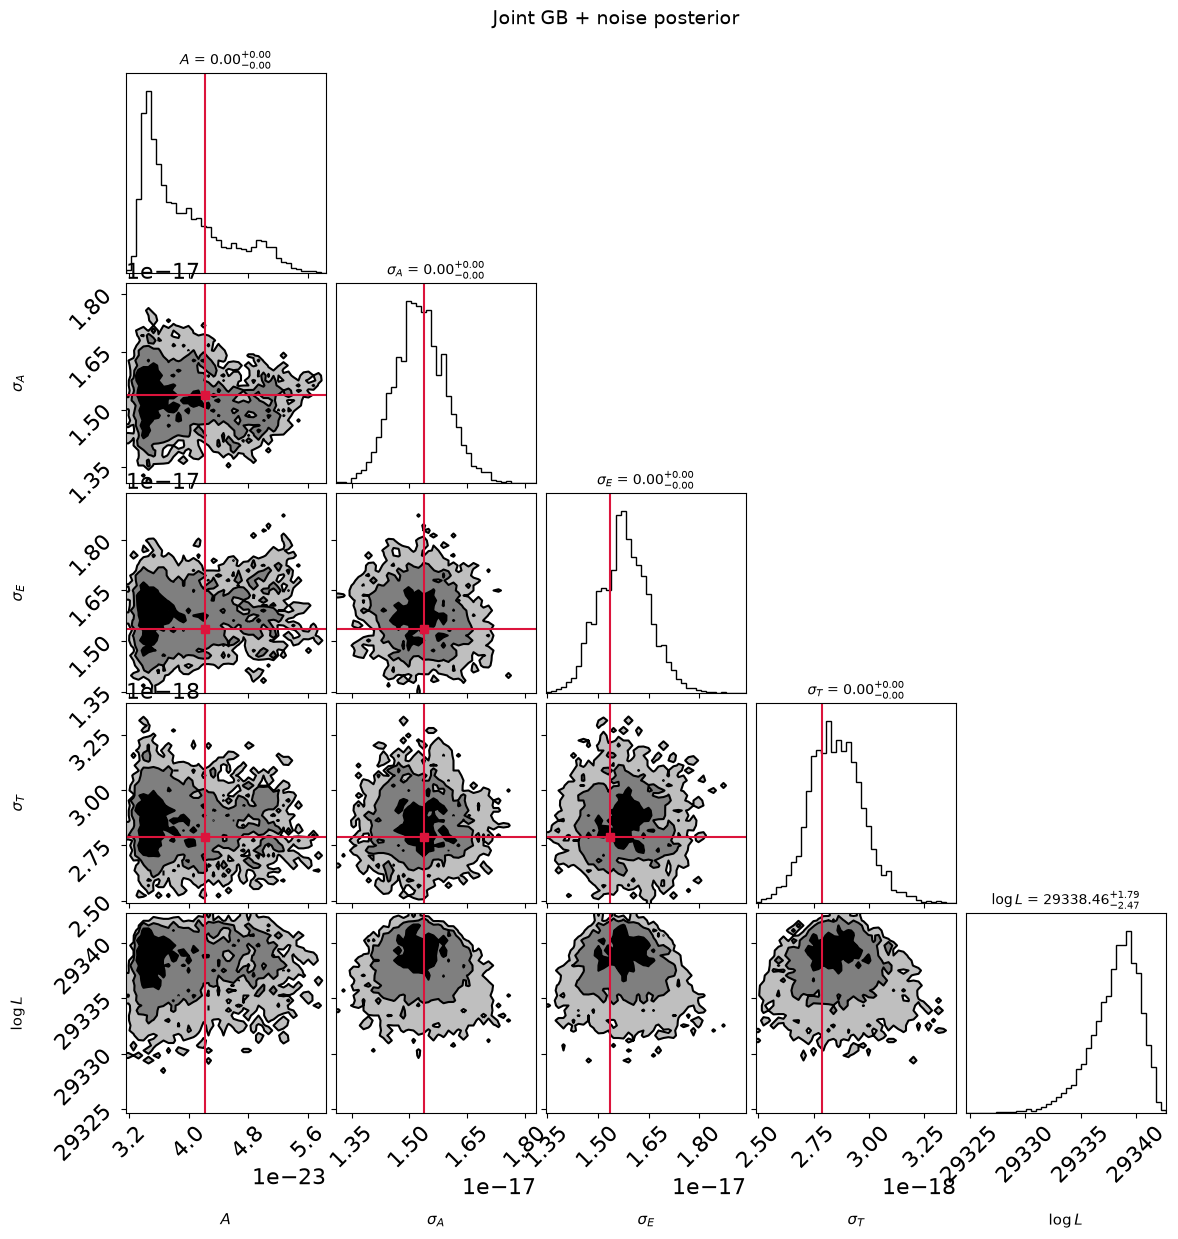

In [27]:
plot_posterior(samples_n, logl_n, truth_n, labels_n, "Joint GB + noise posterior", indices=[2, 8, 9, 10, 11])

## Does fitting the noise change the source parameters?

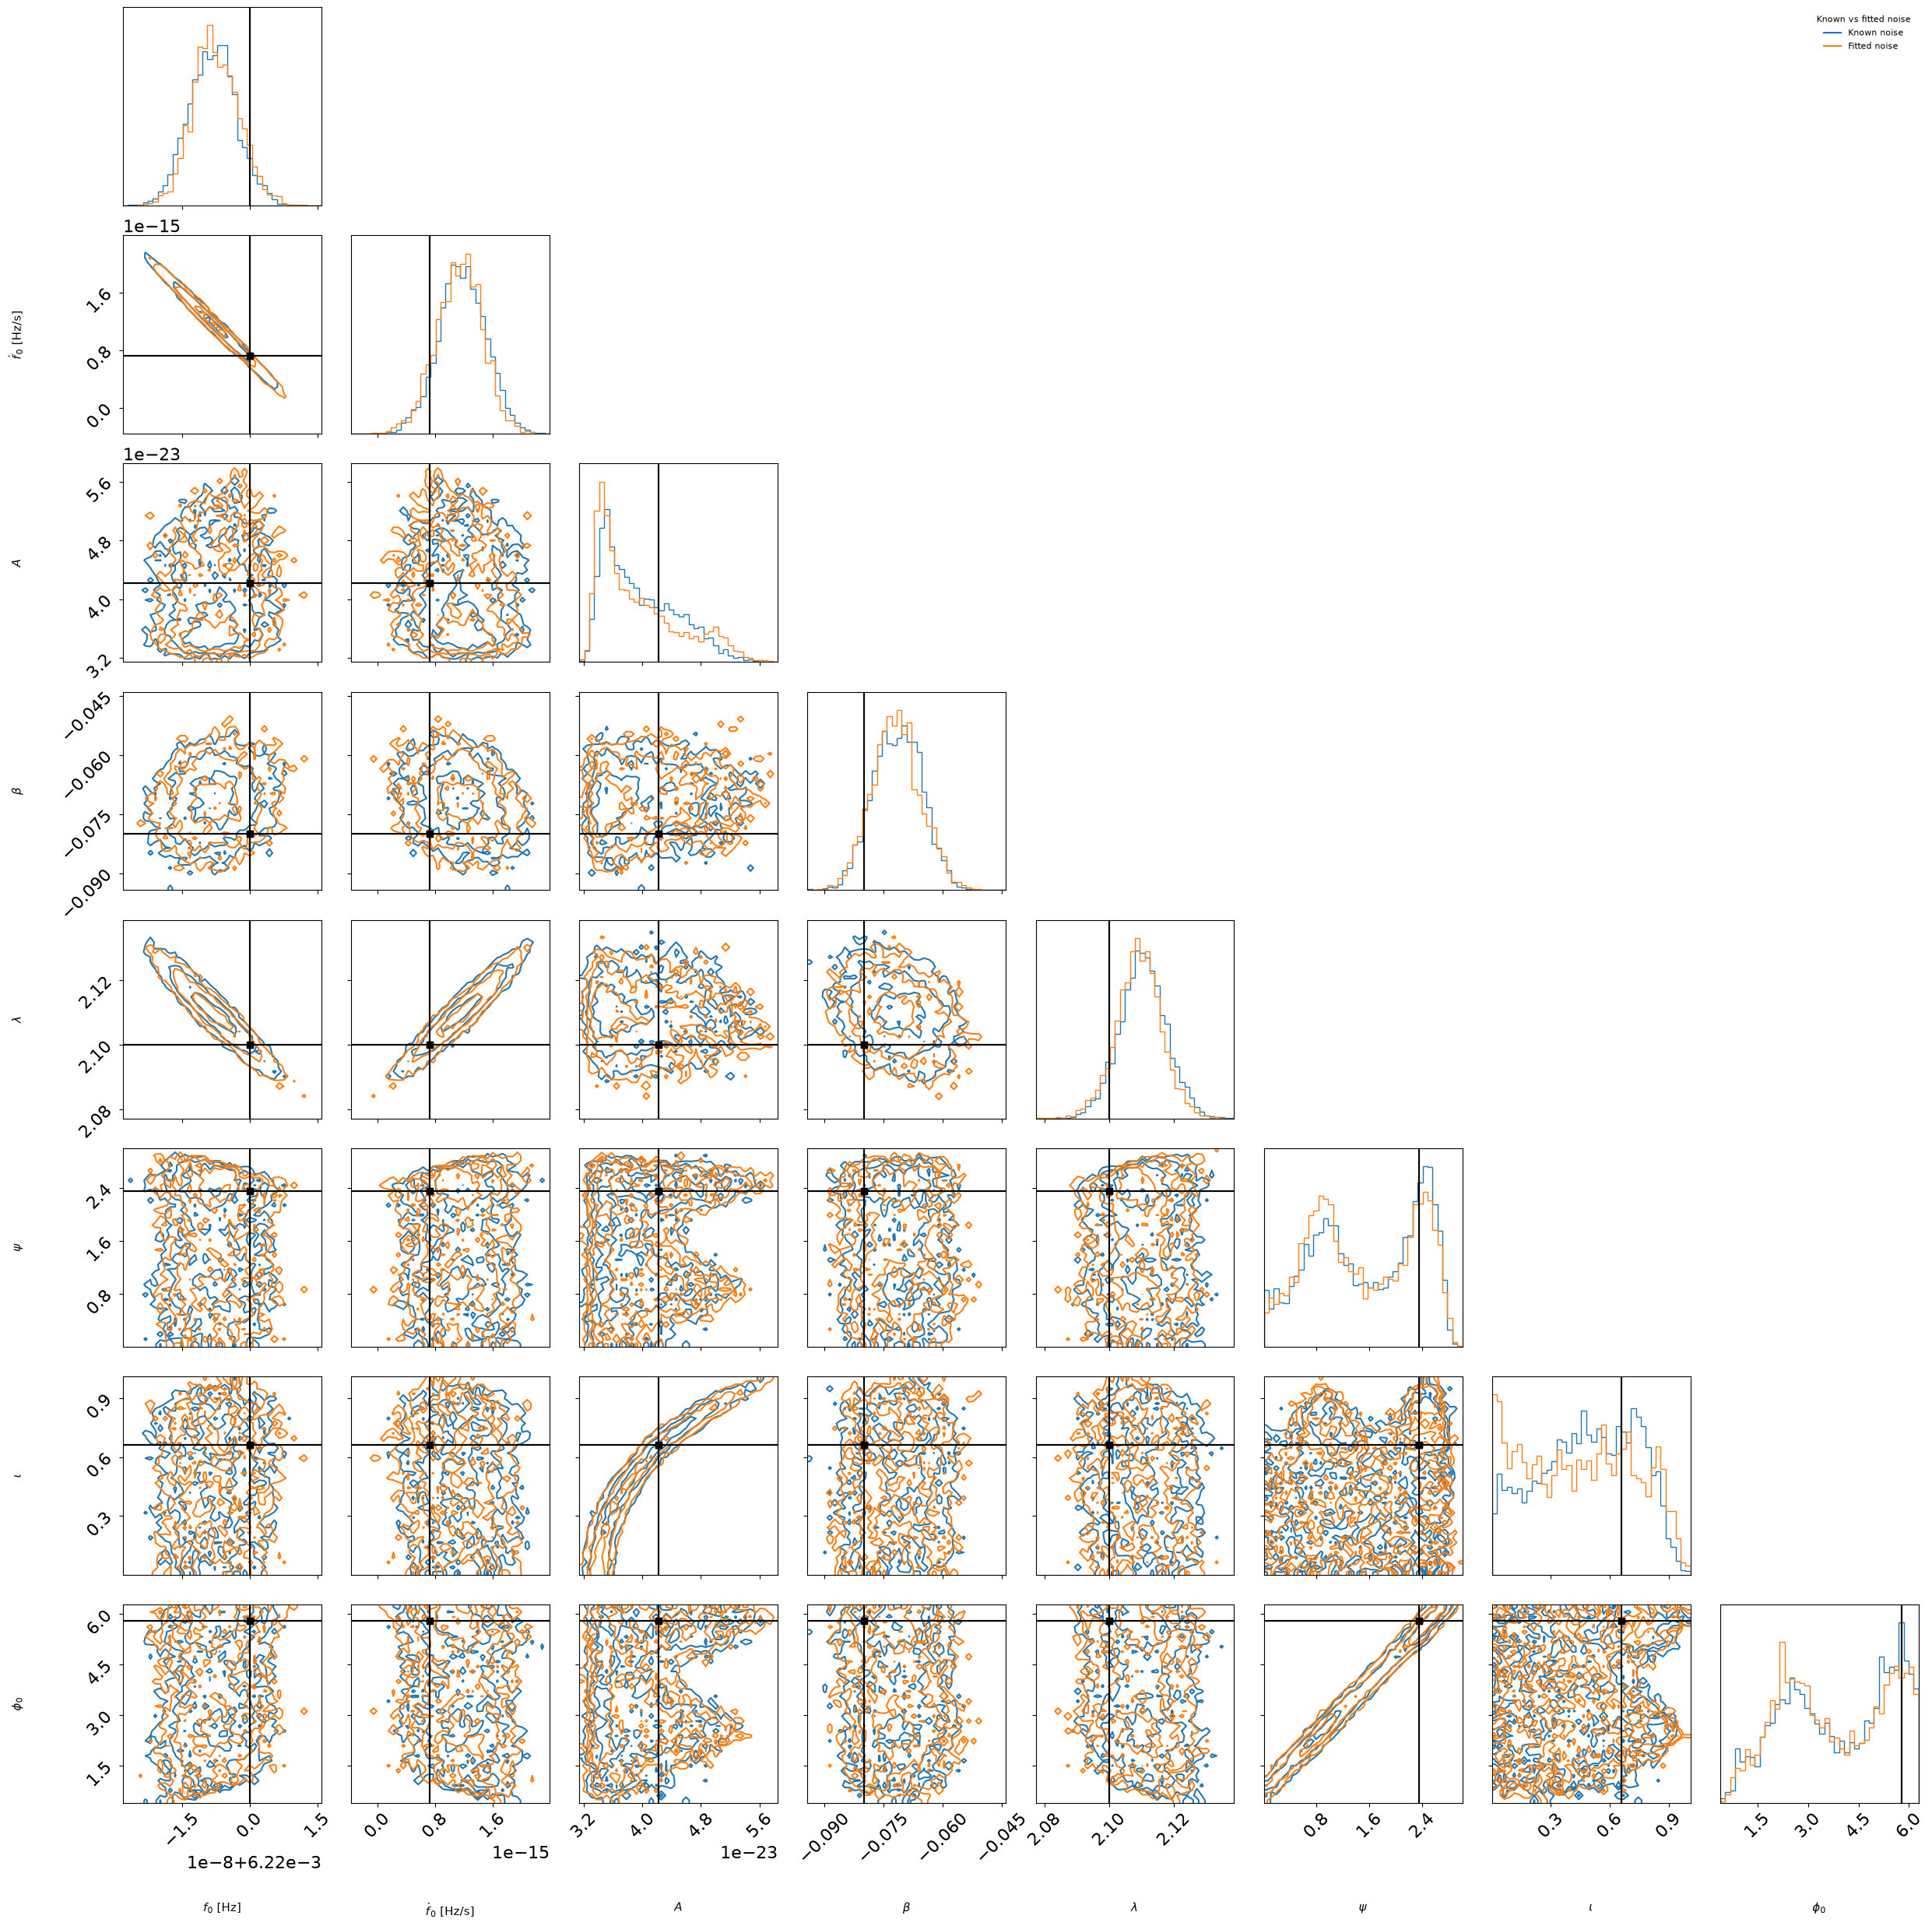

In [28]:
CORNER_OVERLAY = dict(
    labels=get_parameter_labels(), truths=truth, bins=40,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=False, plot_datapoints=False, fill_contours=False, max_n_ticks=4,
    truth_color="k", labelpad=0.2, label_kwargs=dict(fontsize=11))
overlaid_corner([samples, samples_n[:, :8]], ["Known noise", "Fitted noise"],
                corn_kw=CORNER_OVERLAY, title="Known vs fitted noise")